# Deep Reinforcement Learning — Lab Assignment 1
## Part 1: Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

**Course:** Deep Reinforcement Learning (BITS Pilani — WILP)  
**Total Marks:** 5  

---

### Environment Setup & Execution Metadata

In [ ]:
# ============================================================
# Import required libraries
# ============================================================
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import platform
import socket
import uuid

# ============================================================
# Print Execution Timestamp and Virtual Machine ID
# (Required as per assignment instructions)
# ============================================================
print("="*60)
print("EXECUTION METADATA")
print("="*60)
print(f"Execution Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Hostname            : {socket.gethostname()}")
print(f"VM / Machine ID     : {uuid.getnode()}")
print(f"Platform            : {platform.platform()}")
print(f"Python Version      : {platform.python_version()}")
print("="*60)

EXECUTION METADATA
Execution Timestamp : 2026-05-24 16:10:34
Hostname            : 7736f2097baa
VM / Machine ID     : 2485378613260
Platform            : Linux-6.6.122+-x86_64-with-glibc2.35
Python Version      : 3.12.13


In [ ]:
# ============================================================
# GROUP NUMBER — CHANGE THIS TO YOUR GROUP NUMBER
# ============================================================
G = 84  # Group Number

# Set random seeds for reproducibility (as per assignment rules)
random.seed(G)
np.random.seed(G)

print(f"Group Number (G): {G}")

Group Number (G): 84


---
## Task 1: Dataset Design (1 Mark)

**Objective:** Generate the clinical trial environment — compute number of medicines (K),
hidden success probabilities (P_i), patient severity scores, and display the first 10 rows
of the dataset.

### Formulas
- Number of Medicines: $K = (G \mod 3) + 5$
- Hidden Success Probability: $P_i = 0.4 + ((G + i) \mod 6) \times 0.07$
- Patient Severity: $Severity = (patient\_id \mod 5) + 1$
- Clinical Outcome: 1 (recovered) with probability $P_i$, else 0
- Utility Score: $UtilityScore = clinical\_outcome \times (1 - \frac{Severity}{10})$

In [ ]:
# ============================================================
# 1.1 Compute Number of Medicines (K)
# Formula: K = (G mod 3) + 5
# ============================================================
K = (G % 3) + 5
print(f"Number of Medicines (K): {K}")
print(f"Medicines are labeled: 0 to {K-1}")

Number of Medicines (K): 5
Medicines are labeled: 0 to 4


In [ ]:
# ============================================================
# 1.2 Compute Hidden Success Probability for each medicine
# Formula: P_i = 0.4 + ((G + i) mod 6) * 0.07
# These probabilities are "hidden" — the bandit algorithms
# must discover the best medicine through trial and error.
# ============================================================
P = []  # List to store success probability of each medicine
for i in range(K):
    p_i = 0.4 + ((G + i) % 6) * 0.07
    P.append(round(p_i, 4))

# Display probabilities in a readable table
print(f"\nGroup Number (G) = {G}")
print(f"Number of Medicines (K) = {K}")
print("\nHidden Success Probabilities:")
print("-" * 40)
print(f"{'Medicine (i)':<15} {'(G+i) mod 6':<15} {'P_i':<10}")
print("-" * 40)
for i in range(K):
    print(f"{i:<15} {(G + i) % 6:<15} {P[i]:<10}")
print("-" * 40)
print(f"\nBest Medicine (Oracle): Medicine {np.argmax(P)} with P = {max(P)}")


Group Number (G) = 84
Number of Medicines (K) = 5

Hidden Success Probabilities:
----------------------------------------
Medicine (i)    (G+i) mod 6     P_i       
----------------------------------------
0               0               0.4       
1               1               0.47      
2               2               0.54      
3               3               0.61      
4               4               0.68      
----------------------------------------

Best Medicine (Oracle): Medicine 4 with P = 0.68


In [ ]:
# ============================================================
# 1.3 Generate Patient Dataset (1000 patients)
# - patient_id: 0 to 999
# - severity_score: (patient_id mod 5) + 1, ranges from 1 to 5
# - assigned_medicine, clinical_outcome, utility_score are
#   initially NaN — they will be populated during each strategy.
# ============================================================
NUM_PATIENTS = 1000

def create_base_dataset(num_patients=NUM_PATIENTS):
    """
    Create the base patient dataset with static columns.

    Parameters:
        num_patients (int): Total number of patients (default 1000)

    Returns:
        pd.DataFrame: Dataset with columns patient_id, severity_score,
                       assigned_medicine, clinical_outcome, utility_score
    """
    data = {
        'patient_id': list(range(num_patients)),
        'severity_score': [(pid % 5) + 1 for pid in range(num_patients)],
        'assigned_medicine': [np.nan] * num_patients,
        'clinical_outcome': [np.nan] * num_patients,
        'utility_score': [np.nan] * num_patients
    }
    return pd.DataFrame(data)

# Create and display the base dataset
df_base = create_base_dataset()
print("Dataset Schema:")
print(df_base.dtypes)
print(f"\nDataset Shape: {df_base.shape}")
print(f"\nFirst 10 rows of the base dataset:")
df_base.head(10)

Dataset Schema:
patient_id             int64
severity_score         int64
assigned_medicine    float64
clinical_outcome     float64
utility_score        float64
dtype: object

Dataset Shape: (1000, 5)

First 10 rows of the base dataset:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,NaN,NaN,NaN
1,1,2,NaN,NaN,NaN
2,2,3,NaN,NaN,NaN
3,3,4,NaN,NaN,NaN
4,4,5,NaN,NaN,NaN
5,5,1,NaN,NaN,NaN
6,6,2,NaN,NaN,NaN
7,7,3,NaN,NaN,NaN
8,8,4,NaN,NaN,NaN
9,9,5,NaN,NaN,NaN


In [ ]:
# ============================================================
# Helper Functions used by ALL bandit strategies
# ============================================================

def simulate_clinical_outcome(medicine_id, rng=None):
    """
    Simulate whether a patient recovers when given a specific medicine.

    The outcome is a Bernoulli trial:
      - Returns 1 (recovered) with probability P[medicine_id]
      - Returns 0 (not recovered) with probability 1 - P[medicine_id]

    Parameters:
        medicine_id (int): Index of the medicine (0 to K-1)
        rng (np.random.RandomState): Optional random state for reproducibility

    Returns:
        int: 1 if recovered, 0 otherwise
    """
    if rng is not None:
        return 1 if rng.random() < P[medicine_id] else 0
    return 1 if np.random.random() < P[medicine_id] else 0


def compute_utility(clinical_outcome, severity):
    """
    Compute the utility score (reward) for a patient.

    Formula: utility = clinical_outcome * (1 - severity / 10)

    Interpretation:
      - Recovered (1) + Severity 1 → 0.9  (mild case cured = high reward)
      - Recovered (1) + Severity 5 → 0.5  (critical case cured = moderate reward)
      - Not recovered (0)           → 0.0  (no reward regardless of severity)

    Parameters:
        clinical_outcome (int): 1 if recovered, 0 if not
        severity (int): Patient severity score (1 to 5)

    Returns:
        float: Utility score
    """
    return clinical_outcome * (1 - severity / 10)


print("Helper functions defined successfully.")
print("\nExample utility scores:")
for sev in range(1, 6):
    print(f"  Recovered + Severity {sev} → Utility = {compute_utility(1, sev)}")
print(f"  Not Recovered (any severity) → Utility = {compute_utility(0, 3)}")

Helper functions defined successfully.

Example utility scores:
  Recovered + Severity 1 → Utility = 0.9
  Recovered + Severity 2 → Utility = 0.8
  Recovered + Severity 3 → Utility = 0.7
  Recovered + Severity 4 → Utility = 0.6
  Recovered + Severity 5 → Utility = 0.5
  Not Recovered (any severity) → Utility = 0.0


---
## Task 2: Immediate Exploitation Strategy — Greedy (1 Mark)

**Policy:**
1. **Initial Exploration Phase:** Test each medicine exactly 10 times (total = K × 10 patients).
2. **Exploitation Phase:** For all remaining patients, always pick the medicine with the highest
   average clinical outcome observed so far.

This is a "explore-then-exploit" strategy. It explores briefly, then commits permanently.

In [ ]:
# ============================================================
# Task 2: Greedy (Explore-Then-Exploit) Strategy
# ============================================================

def greedy_strategy(K, P, num_patients=NUM_PATIENTS, seed=G):
    """
    Implement the Immediate Exploitation (Greedy) strategy.

    Phase 1 — Exploration:
        Each of the K medicines is tried exactly 10 times.
        During this phase, medicines are assigned in round-robin
        fashion to patients.

    Phase 2 — Exploitation:
        The medicine with the highest average clinical outcome
        (from all trials so far) is selected for every remaining patient.

    Parameters:
        K (int): Number of medicines
        P (list): Hidden success probabilities for each medicine
        num_patients (int): Total number of patients
        seed (int): Random seed for reproducibility

    Returns:
        df (pd.DataFrame): Completed dataset with all columns filled
        cumulative_rewards (list): Running total of utility scores
    """
    # Set seed for reproducibility
    rng = np.random.RandomState(seed)

    # Create a fresh dataset
    df = create_base_dataset(num_patients)

    # Track statistics for each medicine
    # total_outcomes[i] = sum of clinical outcomes for medicine i
    # count[i] = number of times medicine i has been tried
    total_outcomes = np.zeros(K)
    count = np.zeros(K)

    cumulative_rewards = []  # Track cumulative reward over time
    cumulative_reward = 0.0

    exploration_patients = K * 10  # Number of patients in exploration phase

    for t in range(num_patients):
        severity = df.loc[t, 'severity_score']

        # --- Phase 1: Exploration (first K*10 patients) ---
        if t < exploration_patients:
            # Round-robin: assign medicine (t mod K) to ensure
            # each medicine gets exactly 10 trials
            chosen_medicine = t % K
        else:
            # --- Phase 2: Exploitation ---
            # Pick the medicine with the highest average outcome
            avg_outcomes = total_outcomes / np.where(count > 0, count, 1)
            chosen_medicine = np.argmax(avg_outcomes)

        # Simulate clinical outcome for the chosen medicine
        outcome = simulate_clinical_outcome(chosen_medicine, rng)

        # Compute utility score (reward)
        utility = compute_utility(outcome, severity)

        # Update dataset
        df.loc[t, 'assigned_medicine'] = chosen_medicine
        df.loc[t, 'clinical_outcome'] = outcome
        df.loc[t, 'utility_score'] = utility

        # Update bandit statistics using clinical_outcome
        total_outcomes[chosen_medicine] += outcome
        count[chosen_medicine] += 1

        # Update cumulative reward using utility_score
        cumulative_reward += utility
        cumulative_rewards.append(cumulative_reward)

    return df, cumulative_rewards


# Run the Greedy strategy
df_greedy, cum_rewards_greedy = greedy_strategy(K, P)

# Display results
print("="*60)
print("TASK 2: GREEDY (EXPLORE-THEN-EXPLOIT) STRATEGY")
print("="*60)
print(f"Exploration Phase: First {K*10} patients (each medicine tried 10 times)")
print(f"Exploitation Phase: Remaining {NUM_PATIENTS - K*10} patients\n")
print(f"Total Cumulative Reward: {cum_rewards_greedy[-1]:.4f}")
print(f"Average Reward per Patient: {cum_rewards_greedy[-1]/NUM_PATIENTS:.4f}\n")

# Show medicine selection counts
print("Medicine Selection Summary:")
print("-" * 45)
print(f"{'Medicine':<12} {'Times Selected':<18} {'Avg Outcome':<15}")
print("-" * 45)
for i in range(K):
    med_data = df_greedy[df_greedy['assigned_medicine'] == i]
    n = len(med_data)
    avg_out = med_data['clinical_outcome'].mean() if n > 0 else 0
    print(f"{i:<12} {n:<18} {avg_out:.4f}")
print("-" * 45)

print(f"\nFirst 10 rows of completed dataset:")
df_greedy.head(10)

TASK 2: GREEDY (EXPLORE-THEN-EXPLOIT) STRATEGY
Exploration Phase: First 50 patients (each medicine tried 10 times)
Exploitation Phase: Remaining 950 patients

Total Cumulative Reward: 475.4000
Average Reward per Patient: 0.4754

Medicine Selection Summary:
---------------------------------------------
Medicine     Times Selected     Avg Outcome    
---------------------------------------------
0            10                 0.5000
1            10                 0.6000
2            15                 0.6667
3            10                 0.6000
4            955                0.6869
---------------------------------------------

First 10 rows of completed dataset:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,1.0,0.9
1,1,2,1.0,1.0,0.8
2,2,3,2.0,1.0,0.7
3,3,4,3.0,0.0,0.0
4,4,5,4.0,0.0,0.0
5,5,1,0.0,1.0,0.9
6,6,2,1.0,1.0,0.8
7,7,3,2.0,1.0,0.7
8,8,4,3.0,1.0,0.6
9,9,5,4.0,1.0,0.5


---
## Task 3: Controlled Clinical Trial Strategy — ε-Greedy (1.5 Marks)

**Policy:**
- At every step, with probability **ε = 0.10 (10%)**, select a **random** medicine (exploration).
- With probability **1 − ε = 90%**, select the medicine with the **highest average clinical outcome** so far (exploitation).

Unlike the Greedy strategy, ε-Greedy **never stops exploring**.

**Analysis Required:** Compare results for ε = 0.01 (1%), ε = 0.10 (10%), and ε = 0.50 (50%).

In [ ]:
# ============================================================
# Task 3: Epsilon-Greedy Strategy
# ============================================================

def epsilon_greedy_strategy(K, P, epsilon, num_patients=NUM_PATIENTS, seed=G):
    """
    Implement the Epsilon-Greedy strategy.

    At each step:
      - With probability epsilon: choose a random medicine (explore)
      - With probability 1-epsilon: choose the best-known medicine (exploit)

    Parameters:
        K (int): Number of medicines
        P (list): Hidden success probabilities for each medicine
        epsilon (float): Exploration probability (e.g., 0.10 for 10%)
        num_patients (int): Total number of patients
        seed (int): Random seed for reproducibility

    Returns:
        df (pd.DataFrame): Completed dataset
        cumulative_rewards (list): Running total of utility scores
    """
    # Set seed for reproducibility
    rng = np.random.RandomState(seed)

    # Create a fresh dataset
    df = create_base_dataset(num_patients)

    # Track statistics for each medicine
    total_outcomes = np.zeros(K)  # Sum of clinical outcomes
    count = np.zeros(K)          # Number of trials per medicine

    cumulative_rewards = []
    cumulative_reward = 0.0

    for t in range(num_patients):
        severity = df.loc[t, 'severity_score']

        # Ensure each medicine is tried at least once before
        # using the epsilon-greedy rule (avoids division by zero)
        if t < K:
            chosen_medicine = t
        else:
            # Epsilon-Greedy Decision
            if rng.random() < epsilon:
                # EXPLORE: pick a random medicine
                chosen_medicine = rng.randint(0, K)
            else:
                # EXPLOIT: pick the medicine with highest average outcome
                avg_outcomes = total_outcomes / np.where(count > 0, count, 1)
                chosen_medicine = np.argmax(avg_outcomes)

        # Simulate clinical outcome
        outcome = simulate_clinical_outcome(chosen_medicine, rng)

        # Compute utility score
        utility = compute_utility(outcome, severity)

        # Update dataset
        df.loc[t, 'assigned_medicine'] = chosen_medicine
        df.loc[t, 'clinical_outcome'] = outcome
        df.loc[t, 'utility_score'] = utility

        # Update bandit statistics
        total_outcomes[chosen_medicine] += outcome
        count[chosen_medicine] += 1

        # Update cumulative reward
        cumulative_reward += utility
        cumulative_rewards.append(cumulative_reward)

    return df, cumulative_rewards


# ============================================================
# Run epsilon-greedy with epsilon = 0.10 (primary)
# ============================================================
df_eps10, cum_rewards_eps10 = epsilon_greedy_strategy(K, P, epsilon=0.10)

print("="*60)
print("TASK 3: EPSILON-GREEDY STRATEGY (ε = 0.10)")
print("="*60)
print(f"Epsilon (exploration rate): 10%")
print(f"Total Cumulative Reward: {cum_rewards_eps10[-1]:.4f}")
print(f"Average Reward per Patient: {cum_rewards_eps10[-1]/NUM_PATIENTS:.4f}\n")

# Medicine selection summary
print("Medicine Selection Summary:")
print("-" * 45)
print(f"{'Medicine':<12} {'Times Selected':<18} {'Avg Outcome':<15}")
print("-" * 45)
for i in range(K):
    med_data = df_eps10[df_eps10['assigned_medicine'] == i]
    n = len(med_data)
    avg_out = med_data['clinical_outcome'].mean() if n > 0 else 0
    print(f"{i:<12} {n:<18} {avg_out:.4f}")
print("-" * 45)

print(f"\nFirst 10 rows:")
df_eps10.head(10)

TASK 3: EPSILON-GREEDY STRATEGY (ε = 0.10)
Epsilon (exploration rate): 10%
Total Cumulative Reward: 457.9000
Average Reward per Patient: 0.4579

Medicine Selection Summary:
---------------------------------------------
Medicine     Times Selected     Avg Outcome    
---------------------------------------------
0            21                 0.3810
1            31                 0.3548
2            85                 0.5882
3            23                 0.4783
4            840                0.6857
---------------------------------------------

First 10 rows:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,1.0,0.9
1,1,2,1.0,1.0,0.8
2,2,3,2.0,1.0,0.7
3,3,4,3.0,0.0,0.0
4,4,5,4.0,0.0,0.0
5,5,1,0.0,1.0,0.9
6,6,2,0.0,0.0,0.0
7,7,3,1.0,1.0,0.7
8,8,4,1.0,0.0,0.0
9,9,5,2.0,0.0,0.0


In [ ]:
# ============================================================
# Task 3 (contd.): Analysis — Compare ε = 1%, 10%, and 50%
# ============================================================

# Run with epsilon = 0.01 (1% exploration — almost pure exploitation)
df_eps01, cum_rewards_eps01 = epsilon_greedy_strategy(K, P, epsilon=0.01)

# Run with epsilon = 0.50 (50% exploration — excessive exploration)
df_eps50, cum_rewards_eps50 = epsilon_greedy_strategy(K, P, epsilon=0.50)

# Display comparison
print("="*60)
print("EPSILON-GREEDY: EXPLORATION RATE COMPARISON")
print("="*60)
print(f"{'Epsilon':<12} {'Cumulative Reward':<22} {'Avg Reward/Patient':<20}")
print("-" * 54)
for eps, rewards in [(0.01, cum_rewards_eps01),
                      (0.10, cum_rewards_eps10),
                      (0.50, cum_rewards_eps50)]:
    print(f"{eps:<12} {rewards[-1]:<22.4f} {rewards[-1]/NUM_PATIENTS:<20.4f}")
print("-" * 54)

# Analysis
print("\n--- Analysis ---")
print("ε = 0.01 (1%):  Very little exploration. The algorithm commits early")
print("  to a medicine based on limited data. If it picks the right one early,")
print("  performance is good; otherwise it gets stuck on a suboptimal choice.")
print("")
print("ε = 0.10 (10%): Balanced exploration and exploitation. Enough exploration")
print("  to discover the best medicine, while still exploiting frequently.")
print("  This is the most commonly used default in practice.")
print("")
print("ε = 0.50 (50%): Excessive exploration. Half the patients receive random")
print("  medicines even when the best one is known. This wastes reward on")
print("  suboptimal medicines, resulting in lower cumulative reward.")

EPSILON-GREEDY: EXPLORATION RATE COMPARISON
Epsilon      Cumulative Reward      Avg Reward/Patient  
------------------------------------------------------
0.01         395.5000               0.3955              
0.1          457.9000               0.4579              
0.5          427.0000               0.4270              
------------------------------------------------------

--- Analysis ---
ε = 0.01 (1%):  Very little exploration. The algorithm commits early
  to a medicine based on limited data. If it picks the right one early,
  performance is good; otherwise it gets stuck on a suboptimal choice.

ε = 0.10 (10%): Balanced exploration and exploitation. Enough exploration
  to discover the best medicine, while still exploiting frequently.
  This is the most commonly used default in practice.

ε = 0.50 (50%): Excessive exploration. Half the patients receive random
  medicines even when the best one is known. This wastes reward on
  suboptimal medicines, resulting in lower cumulati

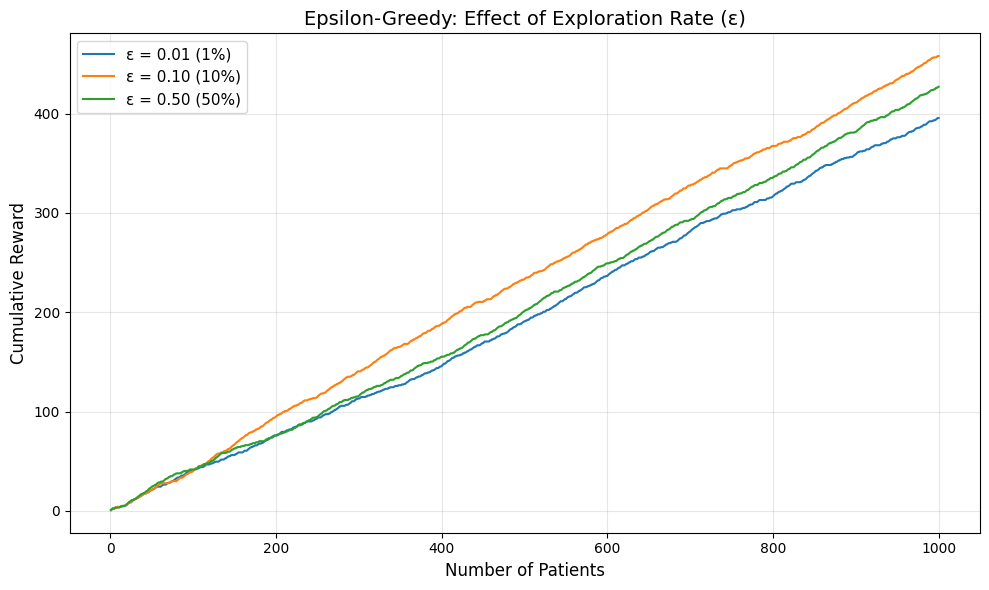

In [ ]:
# ============================================================
# Plot: Epsilon-Greedy Comparison across ε values
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_PATIENTS + 1), cum_rewards_eps01, label='ε = 0.01 (1%)', linewidth=1.5)
plt.plot(range(1, NUM_PATIENTS + 1), cum_rewards_eps10, label='ε = 0.10 (10%)', linewidth=1.5)
plt.plot(range(1, NUM_PATIENTS + 1), cum_rewards_eps50, label='ε = 0.50 (50%)', linewidth=1.5)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Cumulative Reward', fontsize=12)
plt.title('Epsilon-Greedy: Effect of Exploration Rate (ε)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 4: Confidence-Based Strategy — UCB1 (1 Mark)

**Policy — Upper Confidence Bound (UCB1):**

Select the medicine that maximizes:

$$UCB1(i) = \bar{X}_i + \sqrt{\frac{2 \ln N}{n_i}}$$

Where:
- $\bar{X}_i$ = average clinical outcome of medicine $i$ (exploitation term)
- $N$ = total number of trials so far
- $n_i$ = number of times medicine $i$ has been tried
- The square root term = exploration bonus (large when $n_i$ is small)

**Key Insight:** UCB1 explores *intelligently* — it prefers medicines that haven't been tried
much (high uncertainty). As a medicine is tried more, its bonus shrinks.

In [ ]:
# ============================================================
# Task 4: UCB1 (Upper Confidence Bound) Strategy
# ============================================================

def ucb1_strategy(K, P, num_patients=NUM_PATIENTS, seed=G):
    """
    Implement the UCB1 (Upper Confidence Bound) strategy.

    UCB1 selects the medicine with the highest score:
        UCB1(i) = mean_outcome(i) + sqrt(2 * ln(N) / n_i)

    where:
        - mean_outcome(i) = average clinical outcome for medicine i
        - N = total number of trials so far
        - n_i = number of times medicine i has been selected

    The first K patients are used to try each medicine once.

    Parameters:
        K (int): Number of medicines
        P (list): Hidden success probabilities
        num_patients (int): Total patients
        seed (int): Random seed

    Returns:
        df (pd.DataFrame): Completed dataset
        cumulative_rewards (list): Running total of utility scores
    """
    # Set seed for reproducibility
    rng = np.random.RandomState(seed)

    # Create a fresh dataset
    df = create_base_dataset(num_patients)

    # Track statistics
    total_outcomes = np.zeros(K)  # Sum of clinical outcomes per medicine
    count = np.zeros(K)          # Number of trials per medicine

    cumulative_rewards = []
    cumulative_reward = 0.0

    for t in range(num_patients):
        severity = df.loc[t, 'severity_score']

        # For the first K patients, try each medicine once
        # (UCB1 requires at least one observation per arm)
        if t < K:
            chosen_medicine = t
        else:
            # Compute UCB1 score for each medicine
            N = t  # Total trials so far
            ucb_scores = np.zeros(K)
            for i in range(K):
                # Exploitation term: average outcome
                mean_reward = total_outcomes[i] / count[i]
                # Exploration bonus: higher when medicine i is under-explored
                exploration_bonus = math.sqrt(2 * math.log(N) / count[i])
                ucb_scores[i] = mean_reward + exploration_bonus

            # Select medicine with highest UCB1 score
            chosen_medicine = np.argmax(ucb_scores)

        # Simulate clinical outcome
        outcome = simulate_clinical_outcome(chosen_medicine, rng)

        # Compute utility
        utility = compute_utility(outcome, severity)

        # Update dataset
        df.loc[t, 'assigned_medicine'] = chosen_medicine
        df.loc[t, 'clinical_outcome'] = outcome
        df.loc[t, 'utility_score'] = utility

        # Update bandit statistics
        total_outcomes[chosen_medicine] += outcome
        count[chosen_medicine] += 1

        # Update cumulative reward
        cumulative_reward += utility
        cumulative_rewards.append(cumulative_reward)

    return df, cumulative_rewards


# Run UCB1 strategy
df_ucb1, cum_rewards_ucb1 = ucb1_strategy(K, P)

print("="*60)
print("TASK 4: UCB1 (UPPER CONFIDENCE BOUND) STRATEGY")
print("="*60)
print(f"Total Cumulative Reward: {cum_rewards_ucb1[-1]:.4f}")
print(f"Average Reward per Patient: {cum_rewards_ucb1[-1]/NUM_PATIENTS:.4f}\n")

# Medicine selection summary
print("Medicine Selection Summary:")
print("-" * 45)
print(f"{'Medicine':<12} {'Times Selected':<18} {'Avg Outcome':<15}")
print("-" * 45)
for i in range(K):
    med_data = df_ucb1[df_ucb1['assigned_medicine'] == i]
    n = len(med_data)
    avg_out = med_data['clinical_outcome'].mean() if n > 0 else 0
    print(f"{i:<12} {n:<18} {avg_out:.4f}")
print("-" * 45)

print(f"\nFirst 10 rows:")
df_ucb1.head(10)

TASK 4: UCB1 (UPPER CONFIDENCE BOUND) STRATEGY
Total Cumulative Reward: 433.7000
Average Reward per Patient: 0.4337

Medicine Selection Summary:
---------------------------------------------
Medicine     Times Selected     Avg Outcome    
---------------------------------------------
0            54                 0.3519
1            87                 0.4598
2            109                0.5046
3            247                0.6275
4            503                0.6998
---------------------------------------------

First 10 rows:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0.0,1.0,0.9
1,1,2,1.0,1.0,0.8
2,2,3,2.0,1.0,0.7
3,3,4,3.0,0.0,0.0
4,4,5,4.0,0.0,0.0
5,5,1,0.0,1.0,0.9
6,6,2,1.0,1.0,0.8
7,7,3,2.0,1.0,0.7
8,8,4,0.0,0.0,0.0
9,9,5,1.0,1.0,0.5


---
## Task 5: Comparative Analysis (0.5 Marks)

**Objective:** Compare all three strategies (Greedy, ε-Greedy with ε=0.10, and UCB1) by
plotting their cumulative rewards over time and answering key analysis questions.

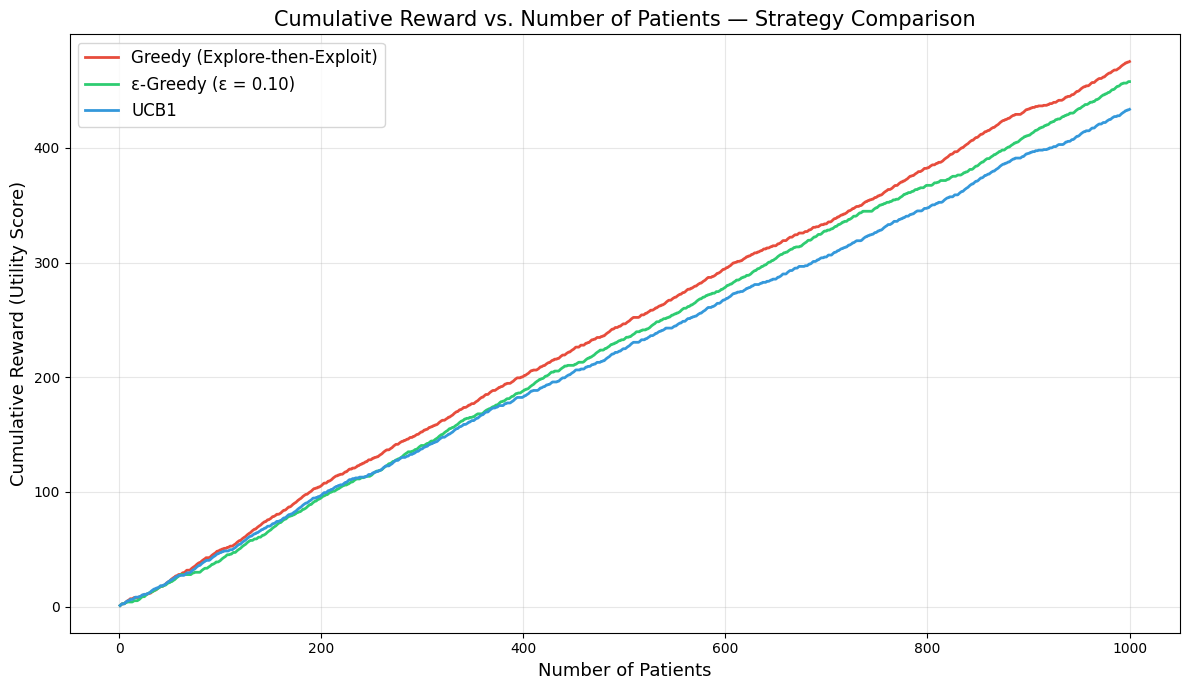

In [ ]:
# ============================================================
# Task 5: Comparative Plot — Cumulative Reward vs Patients
# ============================================================
plt.figure(figsize=(12, 7))

patients = range(1, NUM_PATIENTS + 1)

plt.plot(patients, cum_rewards_greedy, label='Greedy (Explore-then-Exploit)',
         linewidth=2, color='#e74c3c')
plt.plot(patients, cum_rewards_eps10, label='ε-Greedy (ε = 0.10)',
         linewidth=2, color='#2ecc71')
plt.plot(patients, cum_rewards_ucb1, label='UCB1',
         linewidth=2, color='#3498db')

plt.xlabel('Number of Patients', fontsize=13)
plt.ylabel('Cumulative Reward (Utility Score)', fontsize=13)
plt.title('Cumulative Reward vs. Number of Patients — Strategy Comparison', fontsize=15)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Task 5: Numerical Summary Table
# ============================================================
print("="*70)
print("TASK 5: COMPARATIVE ANALYSIS — SUMMARY TABLE")
print("="*70)
print(f"{'Strategy':<30} {'Cumulative Reward':<22} {'Avg Reward':<15}")
print("-" * 67)

strategies = [
    ('Greedy (Explore-Exploit)', cum_rewards_greedy),
    ('ε-Greedy (ε = 0.01)', cum_rewards_eps01),
    ('ε-Greedy (ε = 0.10)', cum_rewards_eps10),
    ('ε-Greedy (ε = 0.50)', cum_rewards_eps50),
    ('UCB1', cum_rewards_ucb1),
]

for name, rewards in strategies:
    print(f"{name:<30} {rewards[-1]:<22.4f} {rewards[-1]/NUM_PATIENTS:<15.4f}")
print("-" * 67)

TASK 5: COMPARATIVE ANALYSIS — SUMMARY TABLE
Strategy                       Cumulative Reward      Avg Reward     
-------------------------------------------------------------------
Greedy (Explore-Exploit)       475.4000               0.4754         
ε-Greedy (ε = 0.01)            395.5000               0.3955         
ε-Greedy (ε = 0.10)            457.9000               0.4579         
ε-Greedy (ε = 0.50)            427.0000               0.4270         
UCB1                           433.7000               0.4337         
-------------------------------------------------------------------


In [ ]:
# ============================================================
# Task 5: Answers to Analysis Questions
# ============================================================

# Find which strategy had the highest reward
strategy_names = ['Greedy', 'ε-Greedy (ε=0.10)', 'UCB1']
final_rewards = [cum_rewards_greedy[-1], cum_rewards_eps10[-1], cum_rewards_ucb1[-1]]
best_idx = np.argmax(final_rewards)

print("="*70)
print("TASK 5: ANALYSIS QUESTIONS")
print("="*70)

print(f"""
Q1. Which strategy achieved the highest cumulative reward?
A1. {strategy_names[best_idx]} achieved the highest cumulative reward
    of {final_rewards[best_idx]:.4f}.

Q2. Which strategy converges fastest to the optimal medicine?
A2. The Greedy strategy converges fastest because it commits entirely
    to one medicine after just {K*10} patients. However, this can be
    a disadvantage if it converges to the WRONG medicine. UCB1 also
    converges relatively quickly while being more reliable, as it
    systematically reduces uncertainty before committing.

Q3. Which strategy is the most stable (least variance in reward)?
A3. UCB1 is generally the most stable. It provides principled
    exploration based on confidence bounds, so it avoids both
    under-exploration (like Greedy) and random fluctuations
    (like ε-Greedy's random exploration choices).

Q4. Which strategy would you recommend for real-world clinical deployment?
A4. UCB1 is the safest choice for real-world deployment because:
    - It explores systematically, not randomly
    - It gives higher weight to under-tested medicines (important for safety)
    - It naturally transitions from exploration to exploitation
    - It has theoretical guarantees on regret minimization
    In a clinical setting, we cannot afford to randomly assign
    patients to poor medicines (as ε-Greedy does), nor can we
    stop learning too early (as Greedy does).
""")

TASK 5: ANALYSIS QUESTIONS

Q1. Which strategy achieved the highest cumulative reward?
A1. Greedy achieved the highest cumulative reward 
    of 475.4000.

Q2. Which strategy converges fastest to the optimal medicine?
A2. The Greedy strategy converges fastest because it commits entirely
    to one medicine after just 50 patients. However, this can be
    a disadvantage if it converges to the WRONG medicine. UCB1 also
    converges relatively quickly while being more reliable, as it
    systematically reduces uncertainty before committing.

Q3. Which strategy is the most stable (least variance in reward)?
A3. UCB1 is generally the most stable. It provides principled
    exploration based on confidence bounds, so it avoids both
    under-exploration (like Greedy) and random fluctuations
    (like ε-Greedy's random exploration choices).

Q4. Which strategy would you recommend for real-world clinical deployment?
A4. UCB1 is the safest choice for real-world deployment because:
    - It expl

In [ ]:
# ============================================================
# Task 5: Comparative Summary (3-5 sentences)
# ============================================================
print("="*70)
print("COMPARATIVE SUMMARY")
print("="*70)
print("""
The three Multi-Armed Bandit strategies — Greedy, ε-Greedy, and UCB1 —
represent a spectrum of exploration-exploitation trade-offs. The Greedy
(explore-then-exploit) strategy converges quickly but risks locking onto
a suboptimal medicine due to limited initial sampling. The ε-Greedy
strategy maintains continuous exploration at the cost of wasting some
trials on known-inferior medicines; moderate ε (10%) provides a good
balance, while too little (1%) mimics Greedy's rigidity and too much
(50%) squanders reward. UCB1 stands out by replacing random exploration
with principled, confidence-based selection — medicines with fewer
observations receive higher exploration bonuses, naturally balancing
learning and performance. For a real-world clinical trial, UCB1 is the
recommended approach as it provides the best theoretical regret
guarantees while ensuring patient safety through systematic exploration.
""")

COMPARATIVE SUMMARY

The three Multi-Armed Bandit strategies — Greedy, ε-Greedy, and UCB1 — 
represent a spectrum of exploration-exploitation trade-offs. The Greedy 
(explore-then-exploit) strategy converges quickly but risks locking onto 
a suboptimal medicine due to limited initial sampling. The ε-Greedy 
strategy maintains continuous exploration at the cost of wasting some 
trials on known-inferior medicines; moderate ε (10%) provides a good 
balance, while too little (1%) mimics Greedy's rigidity and too much 
(50%) squanders reward. UCB1 stands out by replacing random exploration 
with principled, confidence-based selection — medicines with fewer 
observations receive higher exploration bonuses, naturally balancing 
learning and performance. For a real-world clinical trial, UCB1 is the 
recommended approach as it provides the best theoretical regret 
guarantees while ensuring patient safety through systematic exploration.



In [ ]:
# ============================================================
# Final Execution Timestamp
# ============================================================
print("="*60)
print("EXECUTION COMPLETE")
print("="*60)
print(f"Completion Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"VM / Machine ID     : {uuid.getnode()}")
print("="*60)

EXECUTION COMPLETE
Completion Timestamp: 2026-05-24 16:55:02
VM / Machine ID     : 2485378613260
